# Statistical analysis of lop algorithms implementation

## setup

In [25]:
!uv sync


Resolved 46 packages in 2ms
Checked 40 packages in 1ms


In [26]:
import ast
import itertools
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import ttest_rel, wilcoxon


### parameters

#### benchmark parameters

In [27]:

# benchmark parameters
N_WORKERS = -1
N_RUNS = 1
# Guard to avoid benchmarks
RUN_BENCH = False


results_groups = {'cost', 'elapsed_seconds', 'solution'}

#### path
Path of each benchmark file.

In [28]:
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "data" / "input").is_dir() and (PROJECT_ROOT.parent / "data" / "input").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "analysis" / "benchmark_best_known.py").is_file():
    raise FileNotFoundError(f"Could not locate project root from {Path.cwd()}")

PATH_TO_OUT = PROJECT_ROOT / "data" / "output"
PATH_TO_IN = PROJECT_ROOT / "data" / "input"

PATH_TO_BEST_KNOWN = PATH_TO_IN / "best_known.txt"
PATH_TO_INSTANCES = PATH_TO_IN / "instances"
PATH_TO_OUTPUT_IT_IMP = PATH_TO_OUT / "it_im_results.csv"
PATH_TO_OUTPUT_VND = PATH_TO_OUT / "lop_vnd_results.csv"
PATH_TO_OUTPUT_MEM_PARAM = PATH_TO_OUT / "meme_param_results.csv"
PATH_TO_OUTPUT_MEMETIC = PATH_TO_OUT / "meme_results.csv"
PATH_TO_OUTPUT_ILS = PATH_TO_OUT / "ils_results.csv"
PATH_TO_OUTPUT_ILS_PARAM = PATH_TO_OUT / "ils_param_results.csv"

PATH_TO_FIGS = PATH_TO_OUT / "figs"

PATH_BENCHMARK = PROJECT_ROOT / "analysis" / "benchmark_best_known.py"

bench_out = {
    "it_imp": PATH_TO_OUTPUT_IT_IMP,
    "vnd": PATH_TO_OUTPUT_VND,
    "meme_param": PATH_TO_OUTPUT_MEM_PARAM,
    "meme": PATH_TO_OUTPUT_MEMETIC,
    "ils": PATH_TO_OUTPUT_ILS,
    "ils_param": PATH_TO_OUTPUT_ILS_PARAM,
}

# list for loops
benchmark_out = list(bench_out.items())


### functions

In [29]:
def _benchmark_map() -> dict[str, Path]:
    if isinstance(bench_out, dict):
        return bench_out
    if isinstance(benchmark_out, list):
        return {name: path for name, path in benchmark_out}
    raise TypeError(f"bench_out has unexpected type: {type(bench_out)!r}")


def ensure_benchmark(bench: str, outputs: Path | None = None, timeout: int = 0) -> None:
    benchmarks = _benchmark_map()
    if bench not in benchmarks:
        raise ValueError(f"Unknown benchmark: {bench}")
    outputs = outputs or benchmarks[bench]

    if outputs.exists():
        print(f"{bench} benchmark already present. Skipping.")
        return
    elif RUN_BENCH is False:
        print(f"{bench} CSV missing but RUN_BENCH is False — skipping benchmark run.")
        return

    if not PATH_BENCHMARK.exists():
        raise FileNotFoundError(f"Benchmark script not found: {PATH_BENCHMARK}")

    PATH_TO_OUT.mkdir(parents=True, exist_ok=True)

    cmd = [
        "uv",
        "run",
        str(PATH_BENCHMARK),
        "--bench",
        bench,
        "--instances-dir",
        str(PATH_TO_INSTANCES),
        "--best_known_file",
        str(PATH_TO_BEST_KNOWN),
        "--output",
        str(PATH_TO_OUT),
        "--runs",
        str(N_RUNS),
        "--workers",
        str(N_WORKERS),
        "--timeout",
        str(timeout),
    ]
    exit_code = subprocess.call(cmd, cwd=PROJECT_ROOT)
    if exit_code != 0:
        raise RuntimeError(f"Benchmark '{bench}' failed.")


def load_results(csv_path: Path) -> pd.DataFrame:
    """Backward-compatible loader for benchmark CSV outputs."""
    df = pd.read_csv(csv_path).copy()
    if "time_s" not in df.columns and "elapsed_seconds" in df.columns:
        df["time_s"] = df["elapsed_seconds"]
    if "neighborhood_list" not in df.columns:
        if "neighborhoods" in df.columns:
            df["neighborhood_list"] = df["neighborhoods"].map(parse_neighborhoods)
        elif "neighborhood" in df.columns:
            df["neighborhood_list"] = df["neighborhood"].map(parse_neighborhoods)
    if "gap_pct" not in df.columns and {"best_known_cost", "cost"}.issubset(df.columns):
        df["gap_pct"] = 100 * (df["best_known_cost"] - df["cost"]) / df["best_known_cost"]
    return df


def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Compatibility shim for older notebook cells."""
    df = df.copy()
    if "time_s" not in df.columns and "elapsed_seconds" in df.columns:
        df["time_s"] = df["elapsed_seconds"]
    if "neighborhood_list" not in df.columns:
        if "neighborhoods" in df.columns:
            df["neighborhood_list"] = df["neighborhoods"].map(parse_neighborhoods)
        elif "neighborhood" in df.columns:
            df["neighborhood_list"] = df["neighborhood"].map(parse_neighborhoods)
    return df


def load_benchmark(bench: str) -> pd.DataFrame:
    benchmarks = _benchmark_map()
    ensure_benchmark(bench, benchmarks[bench])
    """Load the benchmark results for a given benchmark."""
    if bench not in benchmarks:
        raise ValueError(f"Unknown benchmark: {bench}")
    output_path = benchmarks[bench]
    if not output_path.exists():
        raise FileNotFoundError(f"Benchmark output not found: {output_path}")
    return pd.read_csv(output_path)

def group_by_instance(df:pd.DataFrame):
    set_columns = set(df.columns)
    print(set_columns)
    instance = set_columns.difference(results_groups)
    print(instance)
    group = df.groupby(list(instance))
    return group
    

def df_last_cost(df: pd.DataFrame) -> pd.Series:
    """Extract the last cost value for each instance from the benchmark DataFrame."""
    return group_by_instance(df)["cost"].last()

def df_best_cost(df: pd.DataFrame) -> pd.Series:
    """Extract the best cost value for each instance from the benchmark DataFrame."""
    return group_by_instance(df)["cost"].max()

def df_deviation_from_best(df: pd.DataFrame) -> pd.DataFrame:
    df["rel_deviation"] = 100 * (df["best_known_cost"]- df["cost"]) / df["best_known_cost"]
    return df

In [30]:
def parse_neighborhoods(value: object) -> tuple[str, ...]:
    if isinstance(value, (list, tuple)):
        return tuple(str(item) for item in value)
    parsed = ast.literal_eval(str(value))
    if not isinstance(parsed, (list, tuple)):
        raise ValueError(f"Invalid neighborhoods value: {value}")
    return tuple(str(item) for item in parsed)


def pairwise_test_summary(left_values: np.ndarray, right_values: np.ndarray) -> dict[str, float | int | bool]:
    n_instances = len(left_values)
    if n_instances < 2:
        return {
            "n_instances": n_instances,
            "mean_gap_a": float(left_values.mean()) if n_instances else float("nan"),
            "mean_gap_b": float(right_values.mean()) if n_instances else float("nan"),
            "ttest_p_value": float("nan"),
            "wilcoxon_p_value": float("nan"),
            "significant_5pct_wilcoxon": False,
        }

    _, t_p_value = ttest_rel(left_values, right_values, alternative="two-sided")

    diff = left_values - right_values
    if np.allclose(diff, 0.0):
        _, w_p_value = 0.0, 1.0
    else:
        _, w_p_value = wilcoxon(
            left_values,
            right_values,
            alternative="two-sided",
            zero_method="wilcox",
        )

    return {
        "n_instances": n_instances,
        "mean_gap_a": left_values.mean(),
        "mean_gap_b": right_values.mean(),
        "ttest_p_value": t_p_value,
        "wilcoxon_p_value": w_p_value,
        "significant_5pct_wilcoxon": w_p_value < 0.05,
    }


def run_pairwise_tests(gap_matrix: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for left, right in itertools.combinations(gap_matrix.columns, 2):
        paired = gap_matrix[[left, right]].dropna()
        if paired.empty:
            continue

        left_values = paired[left].to_numpy()
        right_values = paired[right].to_numpy()
        stats = pairwise_test_summary(left_values, right_values)
        rows.append(
            {
                "algorithm_a": left,
                "algorithm_b": right,
                **stats,
            }
        )

    result = pd.DataFrame(rows)
    if result.empty:
        return result
    return result.sort_values("wilcoxon_p_value", na_position="last", ignore_index=True)


In [31]:
def algo_progression(csv_path: Path) -> pd.DataFrame:
    """Return the cost progression over time for each benchmark parameter combination.

    The returned table uses a MultiIndex on the rows made of the algorithm
    parameters plus the instance name, and one column per elapsed time. Each
    cell stores the best-so-far cost reached at that time.
    """
    df = pd.read_csv(csv_path).copy()

    if "elapsed_seconds" not in df.columns and "time_s" in df.columns:
        df["elapsed_seconds"] = df["time_s"]

    if "neighborhoods" in df.columns and "neighborhood" not in df.columns:
        df["neighborhood"] = df["neighborhoods"]

    if "neighborhood" in df.columns:
        df["neighborhood"] = df["neighborhood"].apply(parse_neighborhoods)

    required_columns = {"instance", "cost", "elapsed_seconds"}
    missing_columns = sorted(required_columns - set(df.columns))
    if missing_columns:
        raise ValueError(
            f"{csv_path} is missing required columns: {', '.join(missing_columns)}"
        )

    metric_columns = {"instance", "best_known_cost", "cost", "elapsed_seconds", "time_s", "solution"}
    parameter_columns = [column for column in df.columns if column not in metric_columns]
    if not parameter_columns:
        raise ValueError(f"{csv_path} does not contain any algorithm parameter columns")

    df = df.sort_values(parameter_columns + ["instance", "elapsed_seconds"]).copy()
    df["elapsed_seconds"] = df["elapsed_seconds"].astype(float).round(6)
    df["best_cost_so_far"] = df.groupby(parameter_columns + ["instance"])["cost"].cummax()

    progression = (
        df.pivot_table(
            index=parameter_columns + ["instance"],
            columns="elapsed_seconds",
            values="best_cost_so_far",
            aggfunc="last",
        )
        .sort_index(axis=1)
    )
    progression.columns.name = "elapsed_seconds"
    return progression


In [32]:
def analyze_benchmark(bench: str, csv_path: Path) -> None:
    print(f"\n--- Processing benchmark: {bench} ---")
    # Run the benchmark only if the expected CSV output is missing
    ensure_benchmark(bench, [csv_path])

    # If benchmark run was skipped and CSV still missing, avoid crashing
    if not csv_path.exists():
        print(f"No CSV found for {bench} at {csv_path}; skipping analysis.")
        return

    # Try the strict loader first; fallback to flexible parsing for param-sweep CSVs
    try:
        df = load_results(csv_path)
    except ValueError as exc:
        print(f"load_results failed: {exc}; using flexible loader for {csv_path}")
        df = pd.read_csv(csv_path).copy()
        df = normalize_columns(df)
        # time column fallback
        if "time_s" not in df.columns and "elapsed_seconds" in df.columns:
            df["time_s"] = df["elapsed_seconds"]
        # neighborhood parsing fallback
        if "neighborhoods" in df.columns:
            df["neighborhood_list"] = df["neighborhoods"].map(parse_neighborhoods)
        elif "neighborhood" in df.columns:
            df["neighborhood_list"] = df["neighborhood"].map(lambda v: (v,))
        else:
            # no neighborhood info available -> empty tuple
            df["neighborhood_list"] = [() for _ in range(len(df))]
        # best-known and cost required
        if "best_known_cost" not in df.columns or "cost" not in df.columns:
            raise ValueError(f"Cannot analyze {csv_path}: missing cost/best-known columns")
        df["gap_pct"] = (df["best_known_cost"] - df["cost"]) / df["best_known_cost"] * 100.0

    if df.empty:
        print(f"No rows for {bench} in {csv_path}")
        return

    # Ensure a consistent `algorithm` column for grouping/plotting
    if "algorithm" not in df.columns:
        if "neighborhood_list" in df.columns:
            def _alg_from_neigh(n):
                try:
                    return " -> ".join(n) if len(n) > 1 else n[0]
                except Exception:
                    return str(n)
            df["algorithm"] = df["neighborhood_list"].map(_alg_from_neigh)
        else:
            df["algorithm"] = (
                df.get("sol_start", "").astype(str)
                + " | "
                + df.get("pivot", "").astype(str)
            )

    summary = (
        df.groupby(["algorithm"], as_index=False)
        .agg(
            avg_gap_pct=("gap_pct", "mean"),
            std_gap_pct=("gap_pct", "std"),
            total_time_s=("time_s", "sum"),
        )
        .sort_values("avg_gap_pct", ignore_index=True)
    )

    summary.to_csv(PATH_TO_OUT / f"{bench}_summary_stats.csv", index=False)

    # Build gap matrix; if duplicate instance/algorithm rows exist, aggregate by mean first
    try:
        gap_matrix = df.pivot(index="instance", columns="algorithm", values="gap_pct")
    except Exception as exc:
        print(f"pivot failed ({exc}); aggregating duplicates by mean before pivot")
        gap_matrix = df.groupby(["instance", "algorithm"], as_index=False)["gap_pct"].mean().pivot(index="instance", columns="algorithm", values="gap_pct")

    if gap_matrix.shape[1] >= 2:
        pairwise = run_pairwise_tests(gap_matrix)
        pairwise.to_csv(PATH_TO_OUT / f"{bench}_pairwise_tests.csv", index=False)

    display(summary)

    PATH_TO_FIGS.mkdir(parents=True, exist_ok=True)
    order = summary["algorithm"].tolist()

    fig, ax = plt.subplots(figsize=(6, 6), constrained_layout=True)
    ax.boxplot(
        [df.loc[df["algorithm"] == algo, "gap_pct"] for algo in order],
        tick_labels=order,
        showmeans=True,
    )
    ax.set_title(f"{bench}: instance-wise deviation distribution")
    ax.set_ylabel("Deviation from best-known (%)")
    ax.set_xlabel("Algorithm")
    ax.tick_params(axis="x", rotation=45)

    fig.savefig(PATH_TO_FIGS / f"{bench}_boxplot.svg", format="svg")
    plt.show()

print("Note: RUN_BENCH flag controls whether missing CSVs will be computed. It is currently:", RUN_BENCH)

Note: RUN_BENCH flag controls whether missing CSVs will be computed. It is currently: False


## Iterative improvement
Run benchmarks of iterative improvement 'it_imp'.

it_imp benchmark already present. Skipping.
it_imp benchmark already present. Skipping.
  algo  pivot   neighborhood sol_start       instance  best_known_cost  \
0  vnd  first  ['transpose']    random  N-be75eec_150          3482828   
1  vnd  first  ['transpose']   c_and_w  N-be75eec_150          3482828   
2  vnd  first   ['exchange']    random  N-be75eec_150          3482828   
3  vnd  first   ['exchange']   c_and_w  N-be75eec_150          3482828   
4  vnd  first     ['insert']    random  N-be75eec_150          3482828   

      cost  elapsed_seconds  solution  
0  2169797         0.000013       NaN  
1  2657351         0.000011       NaN  
2  3396593         0.380417       NaN  
3  3379429         0.288687       NaN  
4  3328604         0.146909       NaN  
{'sol_start', 'solution', 'pivot', 'cost', 'algo', 'instance', 'elapsed_seconds', 'neighborhood', 'best_known_cost'}
{'sol_start', 'pivot', 'algo', 'instance', 'neighborhood', 'best_known_cost'}
                                

,sol_start,pivot,neighborhood,algorithm,avg_gap_pct,std_gap_pct,total_time_s
0,random,first,exchange,random | first | exchange,-54.532685,223.423065,28.475114
1,c_and_w,best,insert,c_and_w | best | insert,-53.834816,222.414088,10.226477
2,c_and_w,first,exchange,c_and_w | first | exchange,-53.751785,222.294042,22.896266
3,random,best,exchange,random | best | exchange,-53.483630,221.906343,5.780337
4,random,best,insert,random | best | insert,-53.306876,221.650793,9.579555
5,c_and_w,best,exchange,c_and_w | best | exchange,-52.244900,220.115390,5.086003
6,c_and_w,first,insert,c_and_w | first | insert,-51.648351,219.252901,10.658198
7,random,first,insert,random | first | insert,-51.439432,218.950846,10.578119
8,c_and_w,best,transpose,c_and_w | best | transpose,-21.028105,174.982206,0.004164
9,c_and_w,first,transpose,c_and_w | first | transpose,-20.899850,174.796776,0.001793


,algorithm_a,algorithm_b,n_instances,mean_gap_a,mean_gap_b,ttest_p_value,wilcoxon_p_value,significant_5pct_wilcoxon
0,c_and_w | best | exchange,c_and_w | best | insert,1,-52.244900,-53.834816,NaN,NaN,False
1,c_and_w | best | exchange,c_and_w | best | transpose,1,-52.244900,-21.028105,NaN,NaN,False
2,c_and_w | best | exchange,c_and_w | first | exchange,1,-52.244900,-53.751785,NaN,NaN,False
3,c_and_w | best | exchange,c_and_w | first | insert,1,-52.244900,-51.648351,NaN,NaN,False
4,c_and_w | best | exchange,c_and_w | first | transpose,1,-52.244900,-20.899850,NaN,NaN,False
5,c_and_w | best | exchange,random | best | exchange,1,-52.244900,-53.483630,NaN,NaN,False
6,c_and_w | best | exchange,random | best | insert,1,-52.244900,-53.306876,NaN,NaN,False
7,c_and_w | best | exchange,random | best | transpose,1,-52.244900,0.700102,NaN,NaN,False
8,c_and_w | best | exchange,random | first | exchange,1,-52.244900,-54.532685,NaN,NaN,False
9,c_and_w | best | exchange,random | first | insert,1,-52.244900,-51.439432,NaN,NaN,False


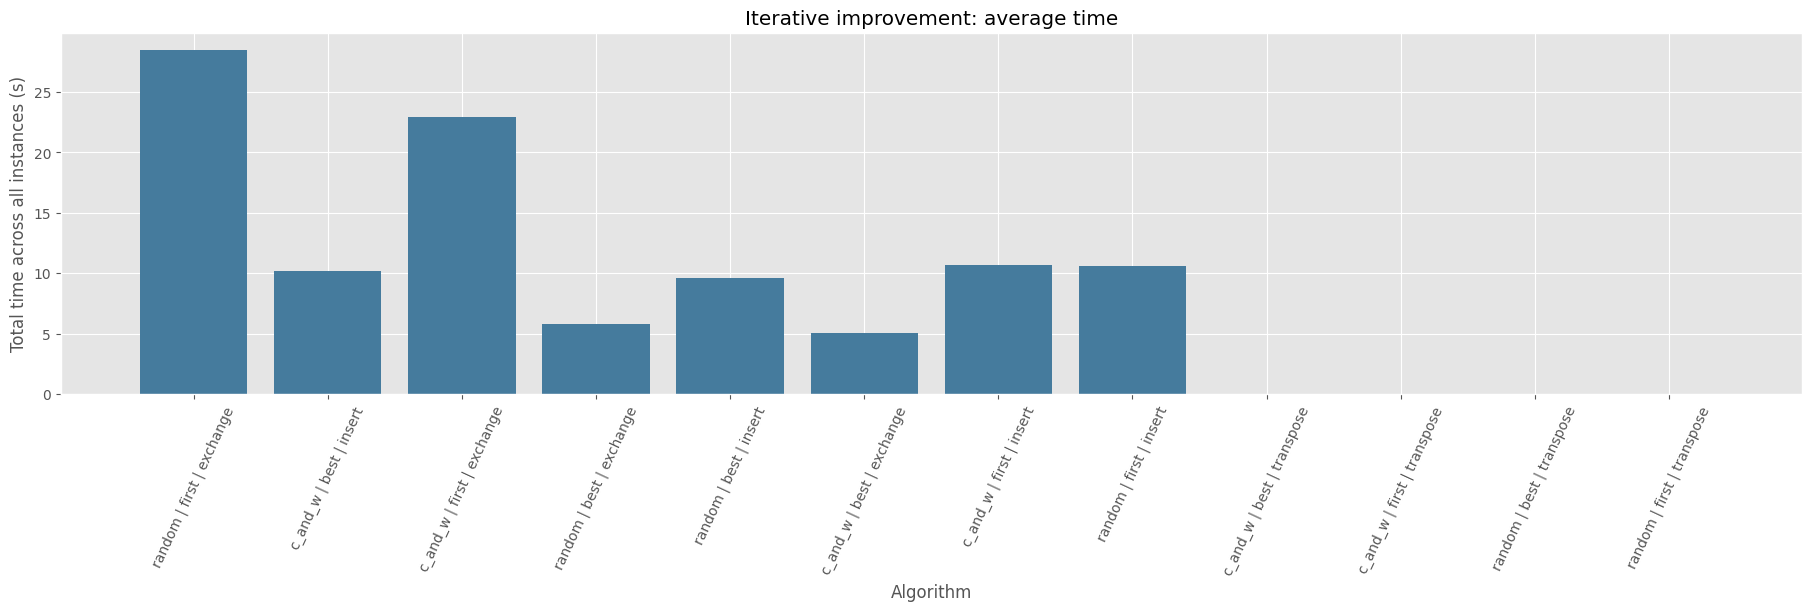

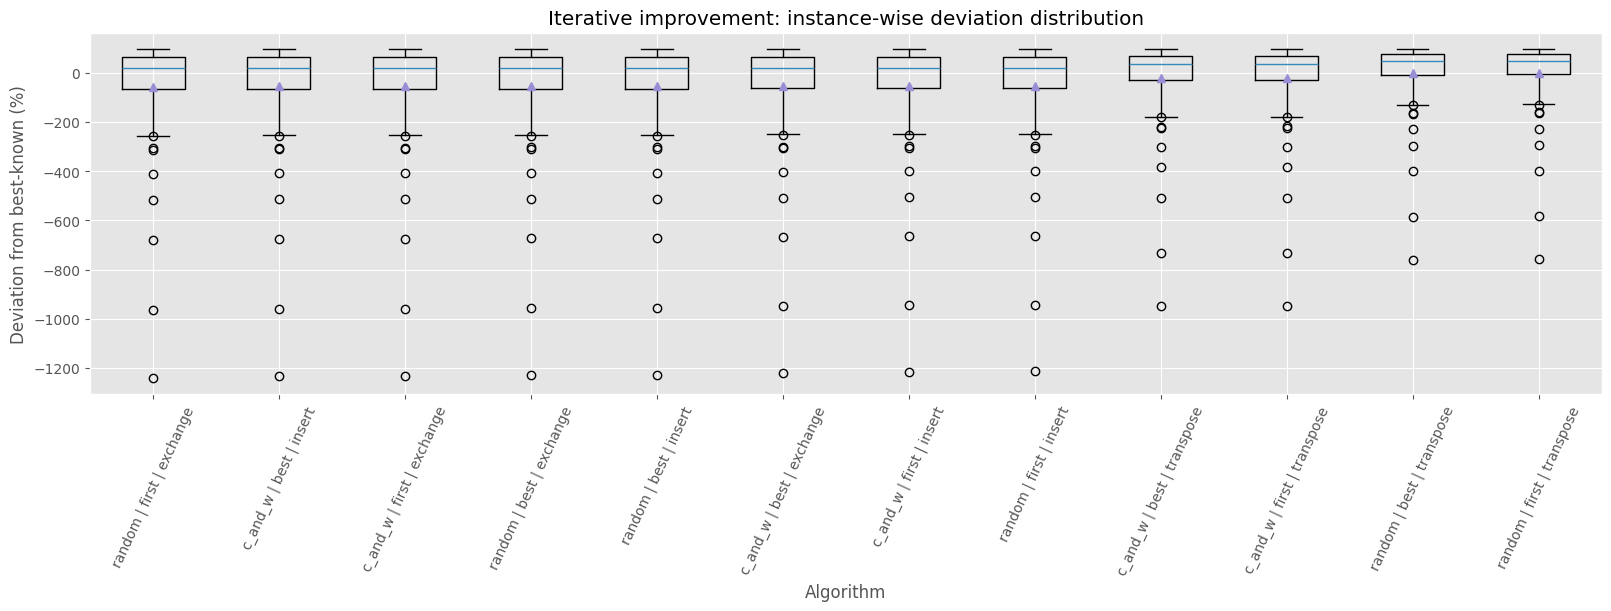

In [33]:
ensure_benchmark("it_imp", PATH_TO_OUTPUT_IT_IMP)
df = load_benchmark("it_imp")
print(df.head())
print(group_by_instance(df).first())


df_it_imp = load_results(PATH_TO_OUTPUT_IT_IMP)
df_it_imp = df_it_imp[df_it_imp["neighborhood_list"].str.len() == 1].copy()
if df_it_imp.empty:
    raise ValueError("No iterative improvement rows found in it_im_results.csv.")

df_it_imp["neighborhood"] = df_it_imp["neighborhood_list"].str[0]
df_it_imp["algorithm"] = (
    df_it_imp["sol_start"] + " | " + df_it_imp["pivot"] + " | " + df_it_imp["neighborhood"]
)

it_summary = (
    df_it_imp.groupby(["sol_start", "pivot", "neighborhood", "algorithm"], as_index=False)
    .agg(
        avg_gap_pct=("gap_pct", "mean"),
        std_gap_pct=("gap_pct", "std"),
        total_time_s=("time_s", "sum"),
    )
    .sort_values(["avg_gap_pct", "total_time_s"], ignore_index=True)
)
it_summary.to_csv(PATH_TO_OUT / "it_im_summary_stats.csv", index=False)

it_gap_matrix = (
    df_it_imp.groupby(["instance", "algorithm"], as_index=False)["gap_pct"]
    .mean()
    .pivot(index="instance", columns="algorithm", values="gap_pct")
)
it_pairwise_tests = run_pairwise_tests(it_gap_matrix)
it_pairwise_tests.to_csv(PATH_TO_OUT / "it_im_pairwise_tests.csv", index=False)

display(it_summary)
display(it_pairwise_tests.head(20))

plt.style.use("ggplot")  # emulate R style
PATH_TO_FIGS.mkdir(parents=True, exist_ok=True)

it_plot = it_summary.sort_values("avg_gap_pct")
it_order = it_plot["algorithm"].tolist()

fig_it_summary, axes = plt.subplots(figsize=(18, 6), constrained_layout=True)
axes.bar(it_plot["algorithm"], it_plot["total_time_s"], color="#457b9d")
axes.set_title("Iterative improvement: average time")
axes.set_ylabel("Total time across all instances (s)")
axes.set_xlabel("Algorithm")
axes.tick_params(axis="x", rotation=65)

fig_it_summary.savefig(PATH_TO_FIGS / "it_imp_summary.svg", format="svg")
plt.show()

fig_it_box, ax = plt.subplots(figsize=(16, 6), constrained_layout=True)
ax.boxplot(
    [df_it_imp.loc[df_it_imp["algorithm"] == algo, "gap_pct"] for algo in it_order],
    tick_labels=it_order,
    showmeans=True,
)
ax.set_title("Iterative improvement: instance-wise deviation distribution")
ax.set_ylabel("Deviation from best-known (%)")
ax.set_xlabel("Algorithm")
ax.tick_params(axis="x", rotation=65)
fig_it_box.savefig(PATH_TO_FIGS / "it_imp_boxplot.svg", format="svg")
plt.show()


## Variable neighborhood descent (VND) algorithm

vnd benchmark already present. Skipping.
vnd benchmark already present. Skipping.
  algo  pivot                         neighborhood sol_start       instance  \
0  vnd  first  ['transpose', 'exchange', 'insert']   c_and_w  N-be75eec_150   
1  vnd  first  ['transpose', 'insert', 'exchange']   c_and_w  N-be75eec_150   
2  vnd  first  ['transpose', 'exchange', 'insert']   c_and_w  N-be75eec_150   
3  vnd  first  ['transpose', 'insert', 'exchange']   c_and_w  N-be75eec_150   
4  vnd  first  ['transpose', 'exchange', 'insert']   c_and_w  N-be75eec_150   

   best_known_cost     cost  elapsed_seconds  solution  
0          3482828  3402876         0.338508       NaN  
1          3482828  3385021         0.174969       NaN  
2          7174325  3402876         0.345685       NaN  
3          7174325  3385021         0.157872       NaN  
4          2246534  3402876         0.365823       NaN  
{'sol_start', 'solution', 'pivot', 'cost', 'algo', 'instance', 'elapsed_seconds', 'neighborhood', 'be

,algorithm,avg_gap_pct,std_gap_pct,total_time_s
0,transpose -> exchange -> insert,-54.818539,223.836352,27.095135
1,transpose -> insert -> exchange,-54.006201,222.661876,13.714172


,algorithm_a,algorithm_b,n_instances,mean_gap_a,mean_gap_b,ttest_p_value,wilcoxon_p_value,significant_5pct_wilcoxon
0,transpose -> exchange -> insert,transpose -> insert -> exchange,1,-54.818539,-54.006201,NaN,NaN,False


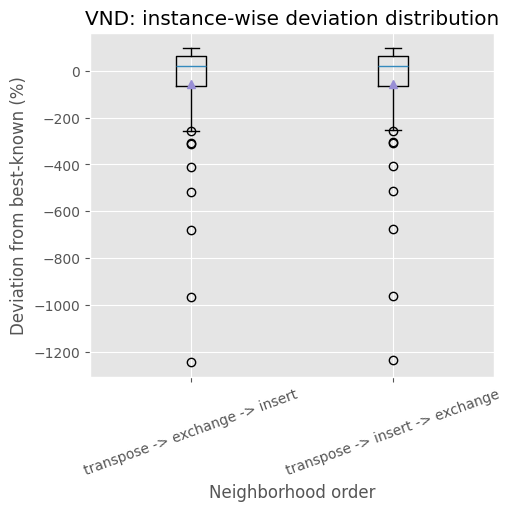

In [34]:
ensure_benchmark("vnd", PATH_TO_OUTPUT_VND)
df = load_benchmark("vnd")
print(df.head())
instances = group_by_instance(df)
print(instances.first())

df_vnd = load_results(PATH_TO_OUTPUT_VND)
df_vnd = df_vnd[df_vnd["neighborhood_list"].str.len() > 1].copy()
if df_vnd.empty:
    raise ValueError("No VND rows found in lop_vnd_results.csv.")

df_vnd["algorithm"] = df_vnd["neighborhood_list"].map(lambda n: " -> ".join(n))

vnd_summary = (
    df_vnd.groupby(["algorithm"], as_index=False)
    .agg(
        avg_gap_pct=("gap_pct", "mean"),
        std_gap_pct=("gap_pct", "std"),
        total_time_s=("time_s", "sum"),
    )
    .sort_values("avg_gap_pct", ignore_index=True)
)
vnd_summary.to_csv(PATH_TO_OUT / "vnd_summary_stats.csv", index=False)

vnd_gap_matrix = (
    df_vnd.groupby(["instance", "algorithm"], as_index=False)["gap_pct"]
    .mean()
    .pivot(index="instance", columns="algorithm", values="gap_pct")
)
if vnd_gap_matrix.shape[1] != 2:
    raise ValueError(f"Expected exactly 2 VND algorithms, got {vnd_gap_matrix.shape[1]}")

vnd_a, vnd_b = vnd_gap_matrix.columns
vnd_paired = vnd_gap_matrix[[vnd_a, vnd_b]].dropna()
vnd_stats = pairwise_test_summary(vnd_paired[vnd_a].to_numpy(), vnd_paired[vnd_b].to_numpy())

vnd_test = pd.DataFrame(
    [
        {
            "algorithm_a": vnd_a,
            "algorithm_b": vnd_b,
            **vnd_stats,
        }
    ]
)

vnd_test.to_csv(PATH_TO_OUT / "vnd_stat_test.csv", index=False)

display(vnd_summary)
display(vnd_test)

PATH_TO_FIGS.mkdir(parents=True, exist_ok=True)

vnd_order = vnd_summary["algorithm"].tolist()
fig_vnd, axes = plt.subplots(figsize=(5, 5), constrained_layout=True)

axes.boxplot(
    [df_vnd.loc[df_vnd["algorithm"] == algo, "gap_pct"] for algo in vnd_order],
    tick_labels=vnd_order,
    showmeans=True,
)
axes.set_title("VND: instance-wise deviation distribution")
axes.set_ylabel("Deviation from best-known (%)")
axes.set_xlabel("Neighborhood order")
axes.tick_params(axis="x", rotation=20)

fig_vnd.savefig(PATH_TO_FIGS / "vnd_summary.svg", format="svg")
plt.show()


## iterative local search (ILS) algorithm

### parameters
Run 'meme_param' benchmark and compare the results. This allow to visualize the effect of the parameters on the solution quality. Only on instances is used to reduce computation time.

In [35]:
analyze_benchmark("ils_param", bench_out["ils_param"])


--- Processing benchmark: ils_param ---


AttributeError: 'list' object has no attribute 'exists'

### instances
Run 'memetic' benchmark on all instances of size 150 and show the deviation from best known solution.

In [ ]:
analyze_benchmark("ils", bench_out["ils"])

## Memetic algorithm
First make the 'meme_param' benchmark, to determine the best parameters for the memetic algorithm. Then run the memetic algorithm with the `memetic` benchmark on all instances of size 150 and analyze the results.

### Parameters
Run 'meme_param' benchmark and compare the results. 

In [ ]:
ensure_benchmark("meme_param", PATH_TO_OUTPUT_MEM_PARAM)
df = load_benchmark("meme_param")
print(df.head())
df["rel_deviation"] = 100 * (df["best_known_cost"]- df["cost"]) / df["best_known_cost"]
results = results_groups.copy()
results.add("rel_deviation")
print(f"Results groups: {results}")
non_result_columns = df.columns.difference(list(results))
print(f"Non-result columns: {non_result_columns}")
df = df.groupby(list(non_result_columns))["rel_deviation"].min().reset_index(name="rel_deviation")
meme_cross_rate_mut = df.groupby("meme_cross_rate_mut")["rel_deviation"]
print(meme_cross_rate_mut)
print("cuocuo")
meme_cross_rate_mut.groupby("meme_cross_rate_mut")["rel_deviation"].min()
meme_cross_rate_mut.plot(x="meme_cross_rate_mut", y="rel_deviation", kind="bar", )
print(df)

meme_param benchmark already present. Skipping.
meme_param benchmark already present. Skipping.
      algo  pivot  neighborhood  meme_divers_try  meme_mean_try  \
0  memetic  first  ['exchange']                3             10   
1  memetic  first  ['exchange']                3             10   
2  memetic  first  ['exchange']                3             10   
3  memetic  first  ['exchange']                3             10   
4  memetic  first  ['exchange']                3             10   

   meme_cross_rate_mut  meme_offspring  meme_pop  meme_mut_rate  \
0                  0.0              10        20            0.1   
1                  0.0              10        20            0.1   
2                  0.0              10        20            0.1   
3                  0.0              10        20            0.1   
4                  0.0              10        20            0.1   

   meme_cross_rate       instance  best_known_cost     cost  elapsed_seconds  \
0              0.5

AttributeError: 'SeriesGroupBy' object has no attribute 'groupby'

### instances
Run 'memetic' benchmark to measure the deviation from best known on all instances of size 150.

In [ ]:

df = load_benchmark("meme")
print(df.head())
instances = group_by_instance(df)
print(instances["cost"].max())

meme benchmark already present. Skipping.
meme benchmark already present. Skipping.
      algo pivot                         neighborhood  meme_divers_try  \
0  memetic  best  ['transpose', 'exchange', 'insert']                5   
1  memetic  best  ['transpose', 'exchange', 'insert']                5   
2  memetic  best  ['transpose', 'exchange', 'insert']                5   
3  memetic  best  ['transpose', 'exchange', 'insert']                5   
4  memetic  best  ['transpose', 'exchange', 'insert']                5   

   meme_mean_try  meme_cross_rate_mut  meme_offspring  meme_pop  \
0             30                  0.8              11        25   
1             30                  0.8              11        25   
2             30                  0.8              11        25   
3             30                  0.8              11        25   
4             30                  0.8              11        25   

   meme_mut_rate  meme_cross_rate       instance  best_known_cost   